In [78]:
import pickle, json, matplotlib
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from scipy.signal import find_peaks
#from cupyx.scipy.signal import find_peaks

In [79]:
raw_data = pl.read_parquet('raw_data.parquet.zstd')

In [80]:
print(type(raw_data))
raw_data

<class 'polars.dataframe.frame.DataFrame'>


port_1_p(bar),port_2_p(bar),port_3_p(bar),port_4_p(bar),support_p(bar),tank_p(bar),temp(c)
f32,f32,f32,f32,f32,f32,f32
0.55,12.29,12.42,0.53,12.37,0.53,48.0
0.55,12.32,12.45,0.55,12.37,0.54,48.0
0.54,12.31,12.43,0.54,12.35,0.54,48.0
0.58,12.32,12.43,0.54,12.38,0.55,48.0
0.55,12.3,12.43,0.54,12.36,0.55,48.0
…,…,…,…,…,…,…
14.91,1.2,1.39,1.33,40.91,1.26,48.0
15.03,1.13,1.3,1.28,41.080002,1.22,48.0
15.06,1.12,1.27,1.22,40.290001,1.18,48.0


In [81]:
time_arr = np.arange(0, raw_data.shape[0], 1)/100
time_arr /= 3600
raw_data = raw_data.with_columns(pl.Series(time_arr).alias('time(h)'))
raw_data

port_1_p(bar),port_2_p(bar),port_3_p(bar),port_4_p(bar),support_p(bar),tank_p(bar),temp(c),time(h)
f32,f32,f32,f32,f32,f32,f32,f64
0.55,12.29,12.42,0.53,12.37,0.53,48.0,0.0
0.55,12.32,12.45,0.55,12.37,0.54,48.0,0.000003
0.54,12.31,12.43,0.54,12.35,0.54,48.0,0.000006
0.58,12.32,12.43,0.54,12.38,0.55,48.0,0.000008
0.55,12.3,12.43,0.54,12.36,0.55,48.0,0.000011
…,…,…,…,…,…,…,…
14.91,1.2,1.39,1.33,40.91,1.26,48.0,1405.070181
15.03,1.13,1.3,1.28,41.080002,1.22,48.0,1405.070183
15.06,1.12,1.27,1.22,40.290001,1.18,48.0,1405.070186


Text(0.5, 0, 'Time (hour)')

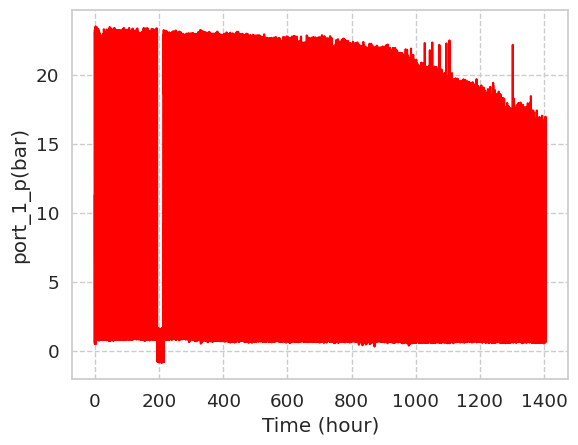

In [84]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(x=time_arr[::100], y=raw_data['port_1_p(bar)'][::100], color='red')

plt.xlabel('Time (hour)')

Text(0.5, 0, 'Time (hour)')

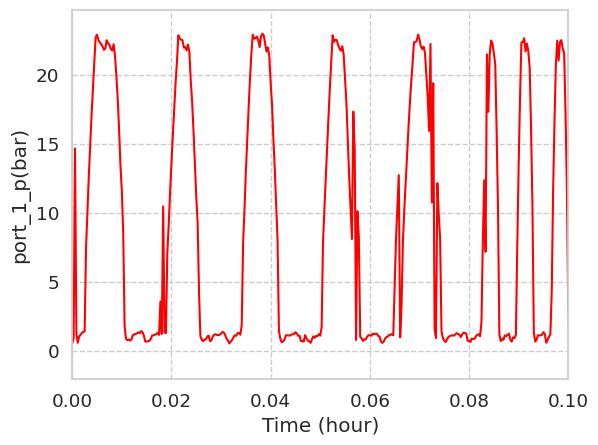

In [85]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(x=time_arr[::100], y=raw_data['port_1_p(bar)'][::100], color='red')

plt.xlim(0, 0.1)
plt.xlabel('Time (hour)')

In [93]:
p1 = np.array(raw_data[:, 0])
time_arr = raw_data['time(h)']

peaks, _ = find_peaks(p1, height=5, distance=200)

In [94]:
peak_p1_pressure = p1[peaks]
peak_p1_time = time_arr[peaks]
peak_p1_pressure.shape

(2086007,)

Text(0, 0.5, 'Pressure (bar)')

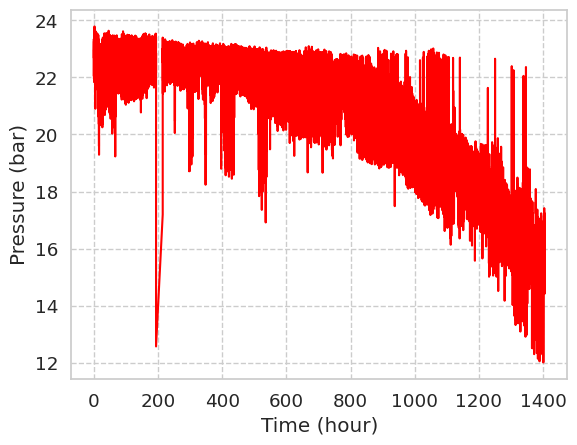

In [95]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(x=peak_p1_time, y=peak_p1_pressure, color='red')

plt.xlabel('Time (hour)')
plt.ylabel('Pressure (bar)')

In [96]:
window_len = 10
window_view = np.lib.stride_tricks.sliding_window_view(peak_p1_pressure, window_shape=window_len)
filtered_peak_p1_pressure = np.median(window_view, axis=1)

pad_arr = np.full(shape=window_len-1, fill_value=filtered_peak_p1_pressure[0])
filtered_peak_p1_pressure = np.concatenate([pad_arr, filtered_peak_p1_pressure])

filtered_peak_p1_pressure.shape

(2086007,)

Text(0, 0.5, 'Pressure (bar)')

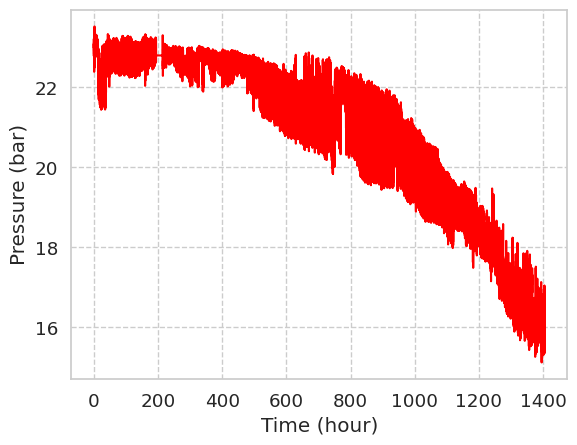

In [97]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(x=peak_p1_time, y=filtered_peak_p1_pressure, color='red')

plt.xlabel('Time (hour)')
plt.ylabel('Pressure (bar)')

In [98]:
p1.shape

(505825270,)

In [99]:
filtered_peak_p1_pressure.shape

(2086007,)

In [102]:
interpol_p1_peak_pressure = np.interp(time_arr, peak_p1_time, filtered_peak_p1_pressure)
interpol_p1_peak_pressure.shape

(505825270,)

<Axes: xlabel='time(h)'>

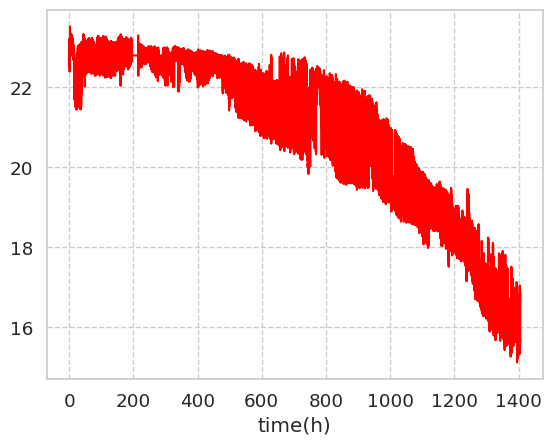

In [101]:
sns.lineplot(x=time_arr[::100], y=interpol_p1_peak_pressure[::100], color='red')

In [113]:
dataset = pl.DataFrame({'time(h)': time_arr, 'p1_pressure': p1, 'peak_p1_pressure': interpol_p1_peak_pressure})
dataset = dataset.with_columns(pl.col(pl.Float64).cast(pl.Float32))

print(dataset.glimpse())

Rows: 505825270
Columns: 3
$ time(h)          <f32> 0.0, 2.7777778086601757e-06, 5.555555617320351e-06, 8.333333425980527e-06, 1.1111111234640703e-05, 1.3888889043300878e-05, 1.6666666851961054e-05, 1.9444443751126528e-05, 2.2222222469281405e-05, 2.499999936844688e-05
$ p1_pressure      <f32> 0.550000011920929, 0.550000011920929, 0.5400000214576721, 0.5799999833106995, 0.550000011920929, 0.6100000143051147, 0.5799999833106995, 0.6000000238418579, 0.5899999737739563, 0.5600000023841858
$ peak_p1_pressure <f32> 22.994998931884766, 22.994998931884766, 22.994998931884766, 22.994998931884766, 22.994998931884766, 22.994998931884766, 22.994998931884766, 22.994998931884766, 22.994998931884766, 22.994998931884766

None


In [114]:
dataset.write_parquet('dataset.zstd', compression='zstd')